In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
from collections import deque

In [3]:
#PART 1 TASK 1
#Read the Dataset from the CSV Files
#column names
columns = [
    "pkSeqID", "Stime", "Flgs", "Proto", "Saddr", "Sport", "Daddr", "Dport",
    "Pkts", "Bytes", "State", "Ltime", "Seq", "Dur", "Mean", "Stddev", "Sum",
    "Min", "Max", "Spkts", "Dpkts", "Sbytes", "Dbytes", "Rate", "Srate", "Drate",
    "TnBPSrcIP", "TnBPDstIP", "TnP_PSrcIP", "TnP_PDstIP", "TnP_PerProto",
    "TnP_Per_Dport", "AR_P_Proto_P_SrcIP", "AR_P_Proto_P_DstIP", "N_IN_Conn_P_SrcIP",
    "N_IN_Conn_P_DstIP", "AR_P_Proto_P_Sport", "AR_P_Proto_P_Dport",
    "Pkts_P_State_P_Protocol_P_DstIP", "Pkts_P_State_P_Protocol_P_SrcIP",
    "Attack", "Category", "Subcategory"
]

#load datasets
df1 = pd.read_csv("UNSW_2018_IoT_Botnet_Dataset_1.csv", header=None, names=columns)
df3 = pd.read_csv("UNSW_2018_IoT_Botnet_Dataset_3.csv", header=None, names=columns)
df5 = pd.read_csv("UNSW_2018_IoT_Botnet_Dataset_5.csv", header=None, names=columns)

#tag origin
df1["source"] = "Dataset_1"
df3["source"] = "Dataset_3"
df5["source"] = "Dataset_5"

#combine
df_combined = pd.concat([df1, df3, df5], ignore_index=True)

#preview
df_combined.head()


<ipython-input-3-5a61bb9c9c25>:14: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("UNSW_2018_IoT_Botnet_Dataset_1.csv", header=None, names=columns)


,pkSeqID,Stime,Flgs,Proto,Saddr,Sport,Daddr,Dport,Pkts,Bytes,...,N_IN_Conn_P_SrcIP,N_IN_Conn_P_DstIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DstIP,Pkts_P_State_P_Protocol_P_SrcIP,Attack,Category,Subcategory,source
0,1,1.526344e+09,e,arp,192.168.100.1,NaN,192.168.100.3,NaN,4,240,...,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dataset_1
1,2,1.526344e+09,e,tcp,192.168.100.7,139,192.168.100.4,36390,10,680,...,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dataset_1
2,3,1.526344e+09,e,udp,192.168.100.149,51838,27.124.125.250,123,2,180,...,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dataset_1
3,4,1.526344e+09,e,arp,192.168.100.4,NaN,192.168.100.7,NaN,10,510,...,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dataset_1
4,5,1.526344e+09,e,udp,192.168.100.27,58999,192.168.100.1,53,4,630,...,Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dataset_1


In [4]:
#TASK 2
#describe each attribute
attribute_descriptions = {
    "pkSeqID": "Row Identifier",
    "Stime": "Record start time (timestamp)",
    "Flgs": "Flow state flags (text)",
    "Proto": "Protocol used (e.g., TCP, UDP, ARP)",
    "Saddr": "Source IP address",
    "Sport": "Source port number",
    "Daddr": "Destination IP address",
    "Dport": "Destination port number",
    "Pkts": "Number of packets in this transaction",
    "Bytes": "Total bytes transferred in the flow",
    "State": "Transaction state (e.g., CON, REQ)",
    "Ltime": "Record last time (timestamp)",
    "Seq": "Argus sequence number",
    "Dur": "Duration of the session (seconds)",
    "Mean": "Average duration of grouped flows",
    "Stddev": "Standard deviation of durations",
    "Sum": "Total duration of grouped flows",
    "Min": "Minimum duration in group",
    "Max": "Maximum duration in group",
    "Spkts": "Packets from source to destination",
    "Dpkts": "Packets from destination to source",
    "Sbytes": "Bytes from source to destination",
    "Dbytes": "Bytes from destination to source",
    "Rate": "Packets/sec in flow",
    "Srate": "Source-to-destination packet rate",
    "Drate": "Destination-to-source packet rate",
    "TnBPSrcIP": "Total bytes per source IP",
    "TnBPDstIP": "Total bytes per destination IP",
    "TnP_PSrcIP": "Total packets per source IP",
    "TnP_PDstIP": "Total packets per destination IP",
    "TnP_PerProto": "Total packets per protocol",
    "TnP_Per_Dport": "Total packets per destination port",
    "AR_P_Proto_P_SrcIP": "Avg rate (protocol, source IP)",
    "AR_P_Proto_P_DstIP": "Avg rate (protocol, destination IP)",
    "N_IN_Conn_P_SrcIP": "Inbound connections per source IP",
    "N_IN_Conn_P_DstIP": "Inbound connections per destination IP",
    "AR_P_Proto_P_Sport": "Avg rate (protocol, source port)",
    "AR_P_Proto_P_Dport": "Avg rate (protocol, destination port)",
    "Pkts_P_State_P_Protocol_P_DstIP": "Packets per state, proto, dest IP",
    "Pkts_P_State_P_Protocol_P_SrcIP": "Packets per state, proto, source IP",
    "Attack": "0: Normal, 1: Attack traffic",
    "Category": "Type of attack (DoS, etc.)",
    "Subcategory": "More specific attack type"
}

#print for check
for col, desc in attribute_descriptions.items():
    print(f"{col}: {desc}")


pkSeqID: Row Identifier
Stime: Record start time (timestamp)
Flgs: Flow state flags (text)
Proto: Protocol used (e.g., TCP, UDP, ARP)
Saddr: Source IP address
Sport: Source port number
Daddr: Destination IP address
Dport: Destination port number
Pkts: Number of packets in this transaction
Bytes: Total bytes transferred in the flow
State: Transaction state (e.g., CON, REQ)
Ltime: Record last time (timestamp)
Seq: Argus sequence number
Dur: Duration of the session (seconds)
Mean: Average duration of grouped flows
Stddev: Standard deviation of durations
Sum: Total duration of grouped flows
Min: Minimum duration in group
Max: Maximum duration in group
Spkts: Packets from source to destination
Dpkts: Packets from destination to source
Sbytes: Bytes from source to destination
Dbytes: Bytes from destination to source
Rate: Packets/sec in flow
Srate: Source-to-destination packet rate
Drate: Destination-to-source packet rate
TnBPSrcIP: Total bytes per source IP
TnBPDstIP: Total bytes per destin

In [6]:
#TASK 3
#describe relations between attributes

#relation 1:average packets per protocol
print(df_combined.groupby("Proto")["Pkts"].mean())

#relation 2:average duration per category (attack type)
print(df_combined.groupby("Category")["Dur"].mean())

#relation 3:number of flows per state
print(df_combined["State"].value_counts())


Proto
arp          28.124542
icmp          1.127866
ipv6-icmp     1.000000
tcp           5.348642
udp          67.833313
Name: Pkts, dtype: float64
Series([], Name: Dur, dtype: float64)
State
RST    1889102
REQ    1017122
INT      40570
URP      26586
FIN      23761
CON       2724
ACC         76
NRS         39
ECO         16
PAR          4
Name: count, dtype: int64


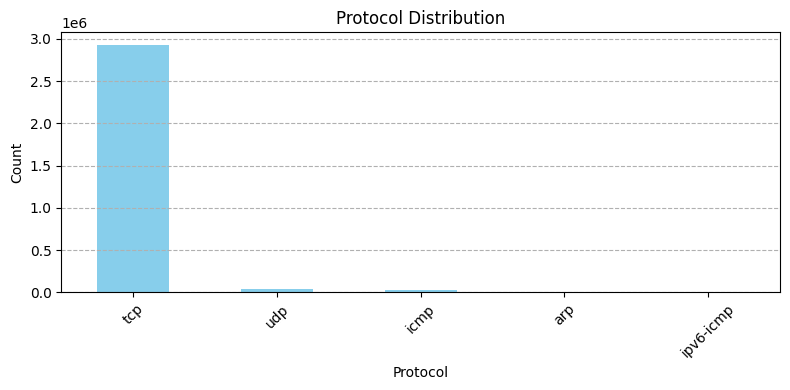

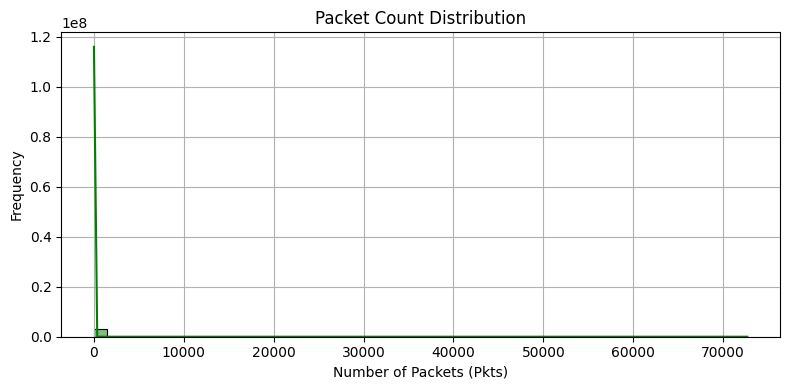

Non-null 'Category' counts by dataset:
source
Dataset_1    0
Dataset_3    0
Dataset_5    0
Name: Category, dtype: int64
No non-null values found in 'Category' column.


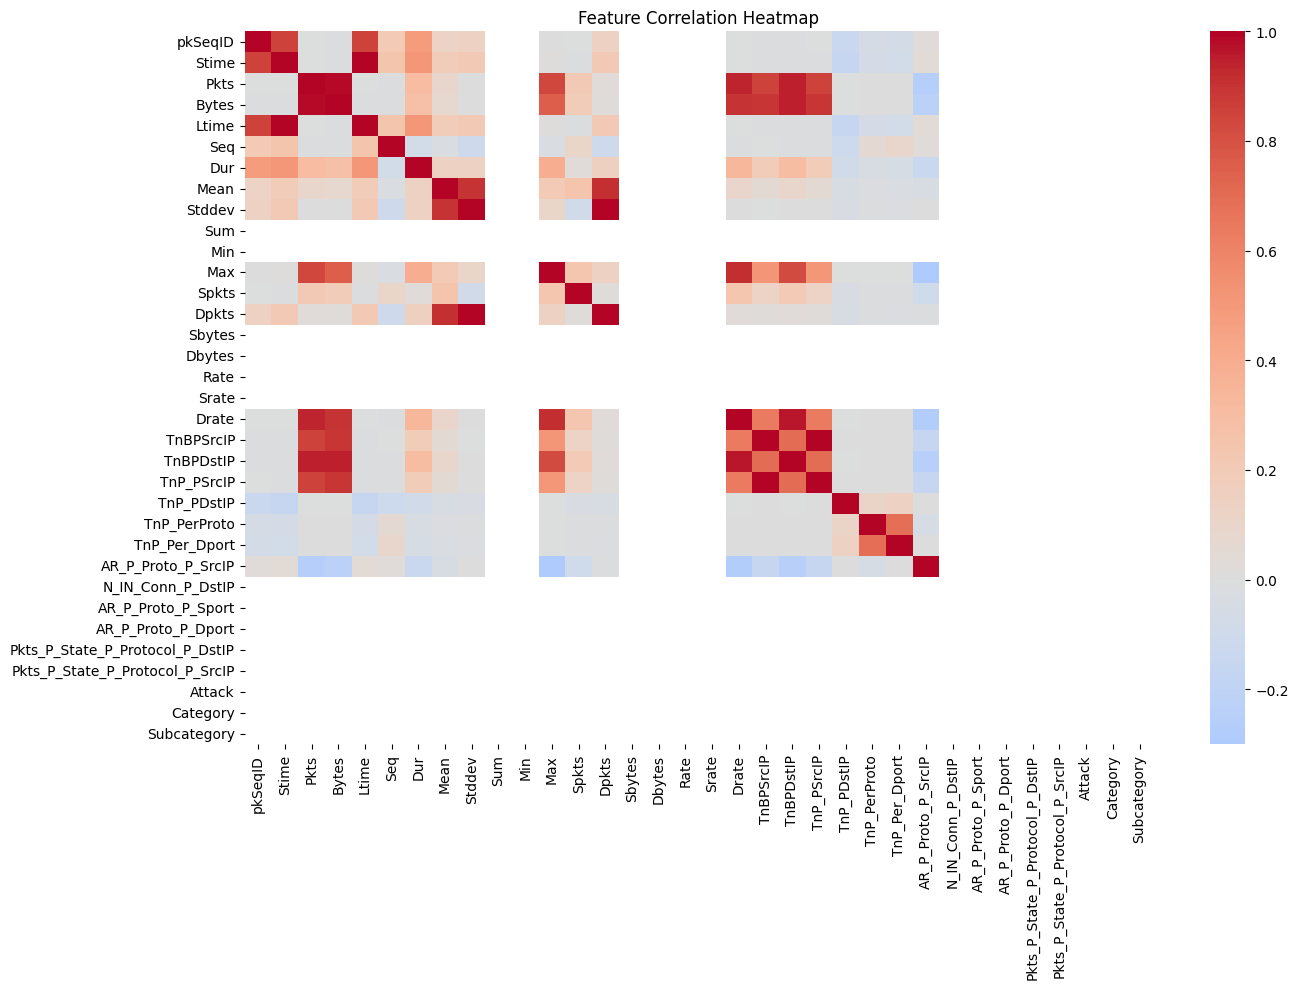

In [10]:
#Task 4: Use Statistical Tools and Charts
# Plot 1: Protocol Distribution
# Ensure inline plotting for Jupyter/Colab
%matplotlib inline

# --------- P1: Protocol Distribution ---------
plt.figure(figsize=(8,4))
df_combined["Proto"].value_counts().plot(kind='bar', color='skyblue')
plt.title("Protocol Distribution")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# --------- P2: Histogram of Packet Counts ---------
plt.figure(figsize=(8,4))
sns.histplot(df_combined["Pkts"], bins=50, kde=True, color='green')
plt.title("Packet Count Distribution")
plt.xlabel("Number of Packets (Pkts)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------- P3: Attack Category Count (only if not empty) ---------
# Step 1: Show how many non-null Category values exist per dataset
category_check = df_combined.groupby("source")["Category"].apply(lambda x: x.notna().sum())
print("Non-null 'Category' counts by dataset:")
print(category_check)

# Step 2:filter for non-empty categories
df_with_categories = df_combined[df_combined["Category"].notna()]

# Step 3:plot only if there's data
if not df_with_categories.empty:
    plt.figure(figsize=(8,4))
    df_with_categories["Category"].value_counts().plot(kind='bar', color='tomato')
    plt.title("Attack Categories")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()
else:
    print("No non-null values found in 'Category' column.")

# --------- P4: correlation heatmap ---------
plt.figure(figsize=(14,10))
sns.heatmap(df_combined.select_dtypes(include='number').corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()



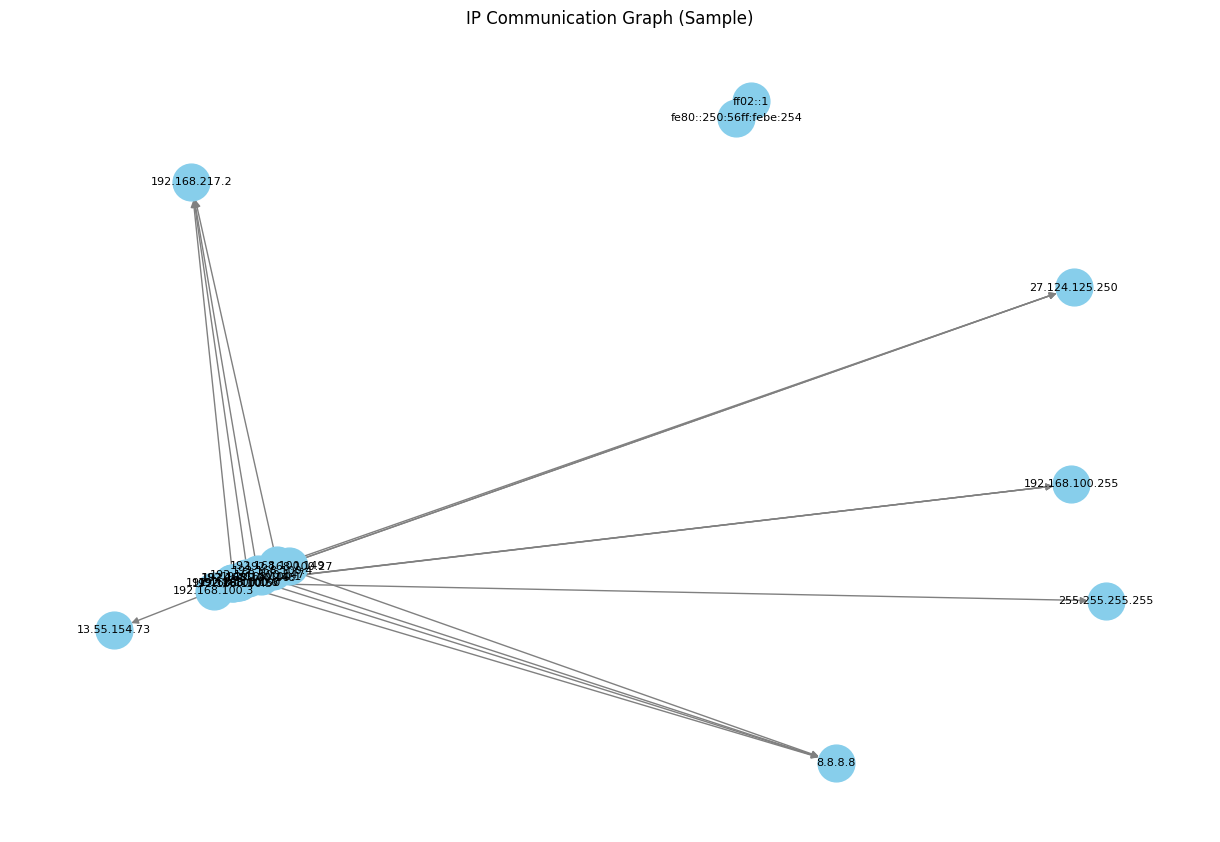

In [11]:
#TASK 5A
# Step 1:create a new directed graph (can use Graph() for undirected)
G_ip = nx.DiGraph()

#Step 2:loop through each row to add edges between source and destination IPs
for idx, row in df_combined.iterrows():
    src = row["Saddr"]
    dst = row["Daddr"]

    #Basic edge with weight as number of packets
    if G_ip.has_edge(src, dst):
        G_ip[src][dst]["weight"] += row["Pkts"]
        G_ip[src][dst]["count"] += 1
    else:
        G_ip.add_edge(src, dst, weight=row["Pkts"], proto=row["Proto"], count=1)

#Step 3: Draw a small sample of the graph (to keep it readable)
subgraph_nodes = list(G_ip.nodes)[:20]  #20 nodes
H = G_ip.subgraph(subgraph_nodes)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(H, seed=42)
nx.draw(H, pos, with_labels=True, node_size=700, node_color="skyblue", edge_color="gray", font_size=8)
plt.title("IP Communication Graph (Sample)")
plt.show()


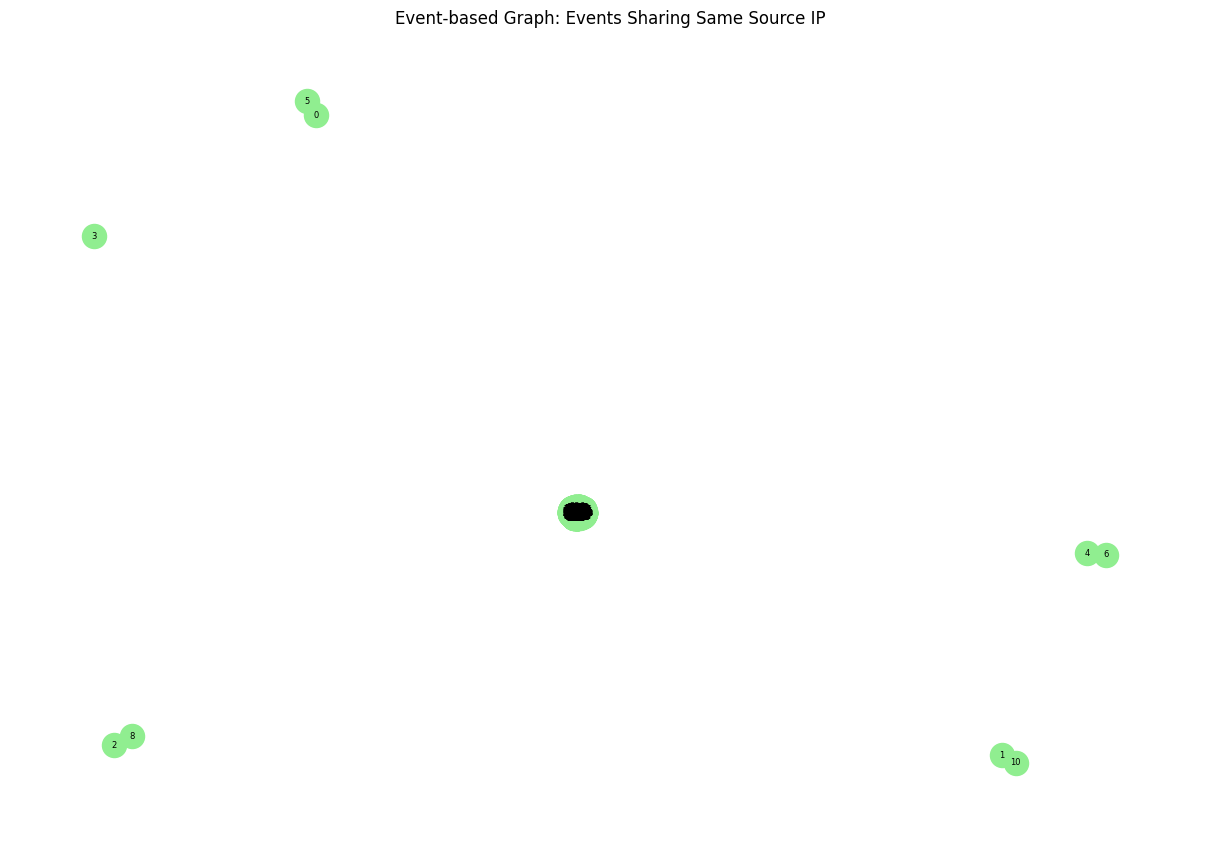

In [12]:
#TASK 5B
#create a new graph for events
G_event = nx.Graph()

#limit to a small sample for performance
df_events_sample = df_combined.head(500)

#step 1: Add each event (row) as a node
for idx, row in df_events_sample.iterrows():
    G_event.add_node(idx, Saddr=row["Saddr"], Daddr=row["Daddr"], Proto=row["Proto"], Pkts=row["Pkts"])

#step 2: Add edges between events with the same source IP
for i in range(len(df_events_sample)):
    for j in range(i+1, len(df_events_sample)):
        if df_events_sample.iloc[i]["Saddr"] == df_events_sample.iloc[j]["Saddr"]:
            G_event.add_edge(i, j)

#step 3: Draw the event graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_event, seed=42)
nx.draw(G_event, pos, with_labels=True, node_size=300, node_color="lightgreen", edge_color="gray", font_size=6)
plt.title("Event-based Graph: Events Sharing Same Source IP")
plt.show()


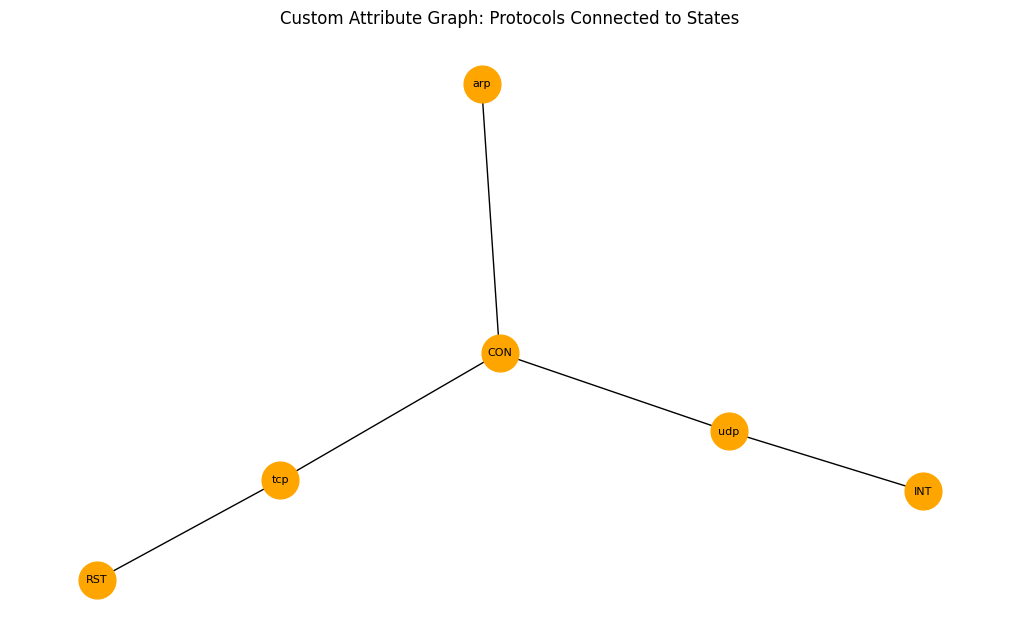

In [13]:
#TASK 5C
#custom graph:protocol and state as nodes
G_custom = nx.Graph()

#sample a small part for simplicity:)
df_sample = df_combined.head(500)

#Step 1: Added protocol and state as nodes
for _, row in df_sample.iterrows():
    proto = row["Proto"]
    state = row["State"]

    if pd.notna(proto) and pd.notna(state):
        G_custom.add_node(proto, type="proto")
        G_custom.add_node(state, type="state")
        G_custom.add_edge(proto, state)

#Step 2: the custom attribute graph
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G_custom, seed=42)
nx.draw(G_custom, pos, with_labels=True, node_size=700, node_color="orange", edge_color="black", font_size=8)
plt.title("Custom Attribute Graph: Protocols Connected to States")
plt.show()


<ipython-input-14-1519feb6f150>:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


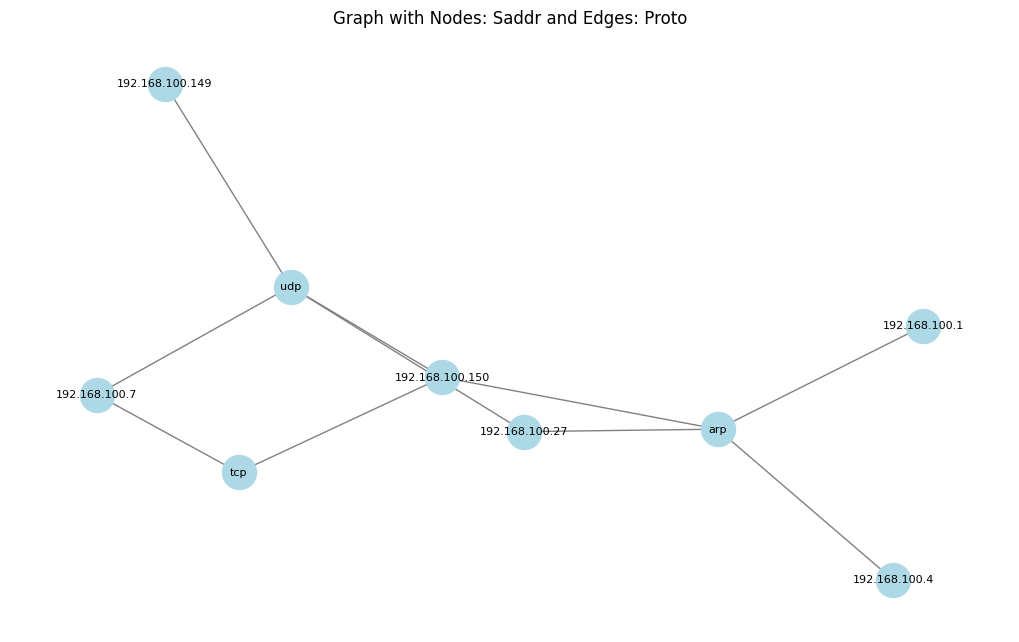

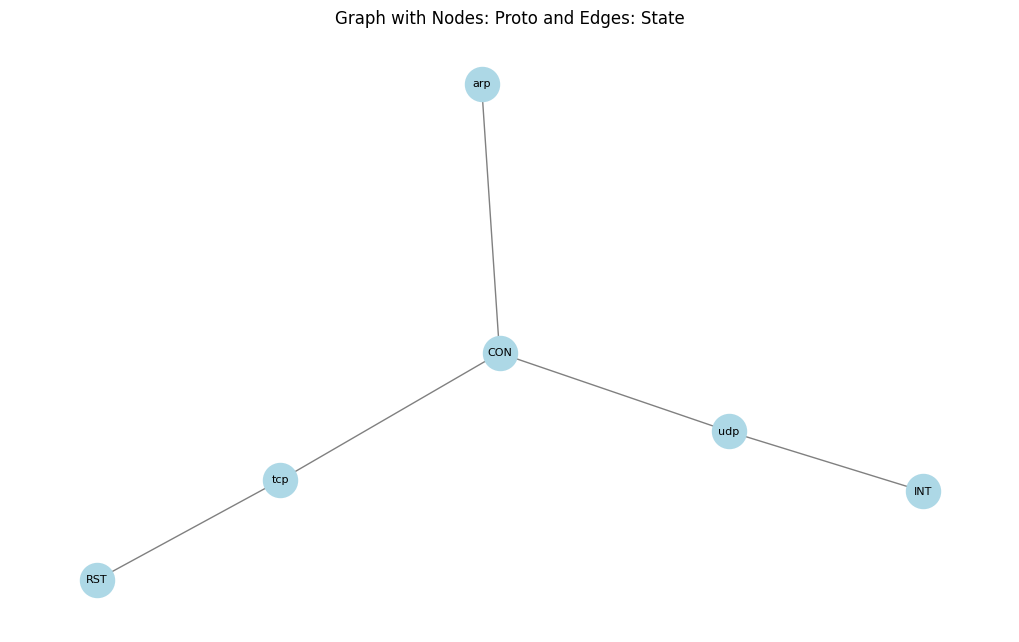

In [14]:
#TASK 6

def build_attribute_graph(df, node_attr, edge_attr=None, max_rows=500):
    """
    Build a graph where:
    - node_attr is used as the node label
    - edge_attr (optional) is used to define a link between two nodes
    """
    G = nx.Graph()
    df_sample = df.head(max_rows)

    if edge_attr:
        # Edge-based graph: edge between node_attr and edge_attr
        for _, row in df_sample.iterrows():
            node = row.get(node_attr)
            edge = row.get(edge_attr)
            if pd.notna(node) and pd.notna(edge):
                G.add_node(node)
                G.add_node(edge)
                G.add_edge(node, edge)
    else:
        # Single attribute: connection of nodes with the same value
        values = df_sample[node_attr].dropna().unique()
        for i in range(len(values)):
            for j in range(i+1, len(values)):
                G.add_edge(values[i], values[j])

    #the graph
    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=600, node_color="lightblue", edge_color="gray", font_size=8)
    plt.title(f"Graph with Nodes: {node_attr}" + (f" and Edges: {edge_attr}" if edge_attr else ""))
    plt.tight_layout()
    plt.show()

# Example usage:
# IPs linked by Protocol
build_attribute_graph(df_combined, node_attr="Saddr", edge_attr="Proto")

# Protocols linked to States
build_attribute_graph(df_combined, node_attr="Proto", edge_attr="State")


<ipython-input-15-f046ac394e2a>:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


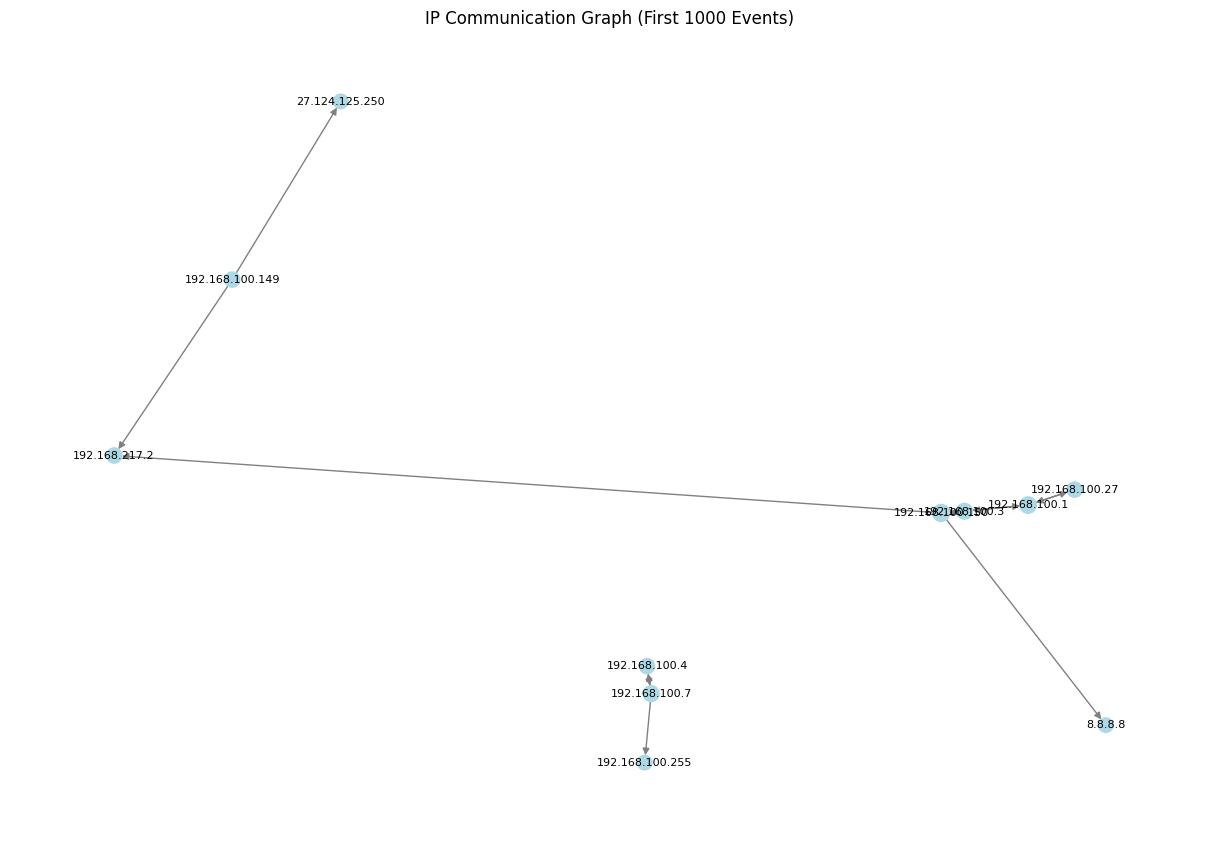

In [15]:
#TASK 7
#rebuilding or reusing the IP graph from Part 2
G_ip = nx.DiGraph()

# added edges using sample data
for idx, row in df_combined.head(1000).iterrows():
    src = row["Saddr"]
    dst = row["Daddr"]
    if pd.notna(src) and pd.notna(dst):
        if G_ip.has_edge(src, dst):
            G_ip[src][dst]["weight"] += row["Pkts"]
            G_ip[src][dst]["count"] += 1
        else:
            G_ip.add_edge(src, dst, weight=row["Pkts"], proto=row["Proto"], count=1)

#drawing the graph with node size based on degree
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_ip, seed=42)
node_sizes = [100 + 10 * G_ip.degree(n) for n in G_ip.nodes()]
nx.draw(G_ip, pos, with_labels=True, node_size=node_sizes, node_color="lightblue", edge_color="gray", font_size=8)
plt.title("IP Communication Graph (First 1000 Events)")
plt.tight_layout()
plt.show()


In [16]:
#TASK 8
def find_path_dfs(graph, start, goal, path=None, visited=None):
    if path is None:
        path = []
    if visited is None:
        visited = set()

    path = path + [start]
    visited.add(start)

    if start == goal:
        return path

    for neighbor in graph.neighbors(start):
        if neighbor not in visited:
            new_path = find_path_dfs(graph, neighbor, goal, path, visited)
            if new_path:
                return new_path

    return None

#checking to find a path between 2 IPs
ip_list = list(G_ip.nodes)
if len(ip_list) >= 2:
    origin_ip = ip_list[0]
    destination_ip = ip_list[1]
    path = find_path_dfs(G_ip, origin_ip, destination_ip)
    print(f"Path from {origin_ip} to {destination_ip}: {path}")
else:
    print("Not enough IPs to demonstrate DFS pathfinding.")


Path from 192.168.100.1 to 192.168.100.3: ['192.168.100.1', '192.168.100.3']


In [17]:
#TASK 9
def calculate_total_packets(graph, path):
    """Sums packet counts (edge weights) along a given path."""
    if not path or len(path) < 2:
        return 0

    total_packets = 0
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        if graph.has_edge(u, v):
            total_packets += graph[u][v].get("weight", 0)

    return total_packets

#reuse the DFS path from earlier
if path:
    total_pkts_dfs = calculate_total_packets(G_ip, path)
    print(f"Total packets along DFS path from {path[0]} to {path[-1]}: {total_pkts_dfs}")
else:
    print("No DFS path found to calculate packets.")

# Comparison: use networkx shortest_path (if available ofc)
try:
    shortest_path = nx.shortest_path(G_ip, source=origin_ip, target=destination_ip)
    total_pkts_shortest = calculate_total_packets(G_ip, shortest_path)
    print(f"Shortest path: {shortest_path}")
    print(f"Total packets along shortest path: {total_pkts_shortest}")
except nx.NetworkXNoPath:
    print("No shortest path found between the selected IPs.")


Total packets along DFS path from 192.168.100.1 to 192.168.100.3: 4
Shortest path: ['192.168.100.1', '192.168.100.3']
Total packets along shortest path: 4


<ipython-input-20-88db552fbc24>:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


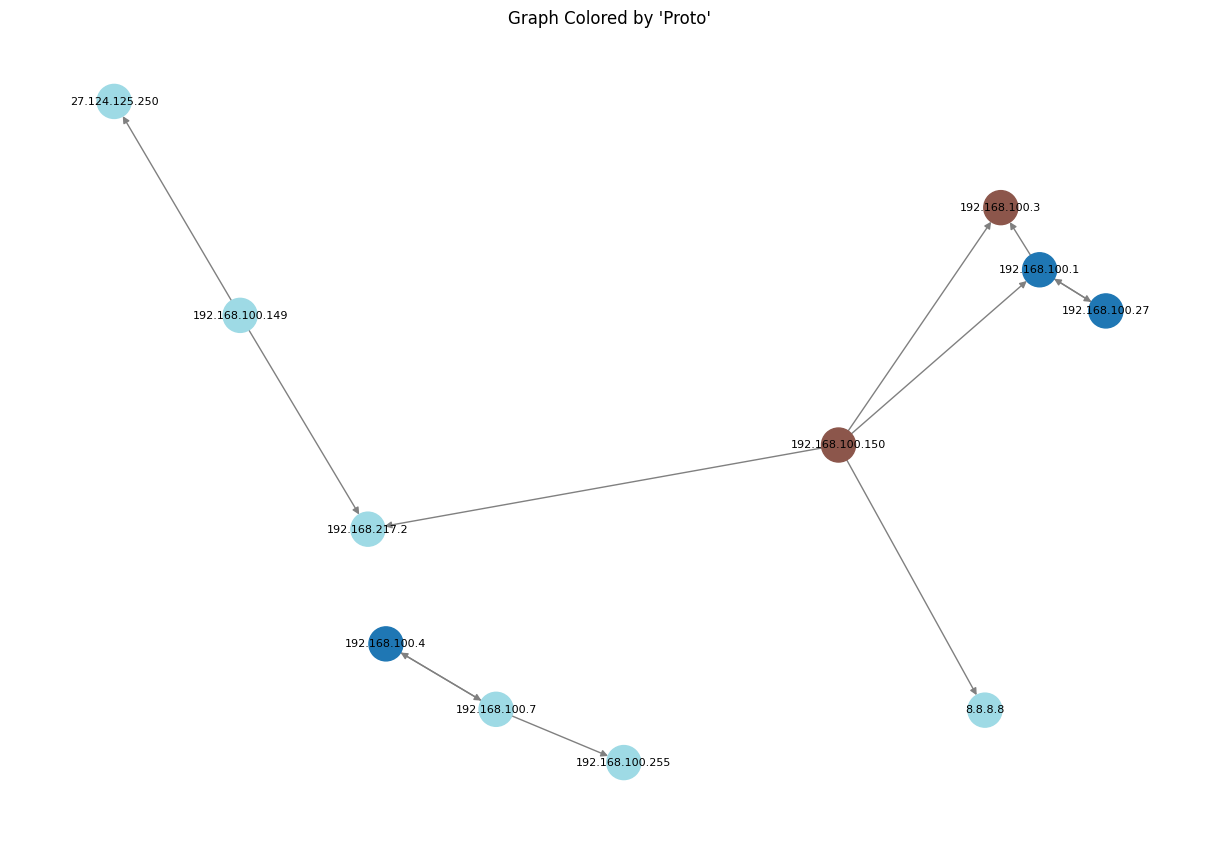

In [20]:
#TASK 10-11
def draw_colored_graph(df, node_attr="Saddr", target_attr="Proto", max_rows=500):
    """
    Draws a graph where:
    - Nodes are from `node_attr` (e.g., Saddr)
    - Color is based on values from `target_attr` (e.g., Proto)
    """
    # Sample the data
    sample = df.head(max_rows)

    # the graph
    G = nx.DiGraph()
    color_map = {}
    proto_to_color = {}
    current_color = 0

    for _, row in sample.iterrows():
        src = row.get("Saddr")
        dst = row.get("Daddr")
        proto = row.get(target_attr)

        if pd.notna(src) and pd.notna(dst):
            G.add_edge(src, dst)

            #color ID
            if proto not in proto_to_color:
                proto_to_color[proto] = current_color
                current_color += 1

            color_map[src] = proto_to_color[proto]
            color_map[dst] = proto_to_color[proto]

    #colors
    node_colors = [color_map.get(node, 0) for node in G.nodes()]

    #draw the graph
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos,
            with_labels=True,
            node_size=600,
            node_color=node_colors,
            cmap=plt.cm.tab20,
            edge_color="gray",
            font_size=8)
    plt.title(f"Graph Colored by '{target_attr}'")
    plt.tight_layout()
    plt.show()

# Example usage
draw_colored_graph(df_combined, node_attr="Saddr", target_attr="Proto")


In [21]:
#TASK 12
#a small, connected subgraph from G_ip
G_sample = G_ip.subgraph(list(G_ip.nodes)[:100]).copy()

#a. degree centrality
deg_centrality = nx.degree_centrality(G_sample)

#b. closeness centrality
closeness = nx.closeness_centrality(G_sample)

#c.betweenness centrality
betweenness = nx.betweenness_centrality(G_sample)

#d.network density
density = nx.density(G_sample)

#e. network diameter
try:
    if not nx.is_strongly_connected(G_sample):
        G_largest = max(nx.strongly_connected_components(G_sample), key=len)
        G_strong = G_sample.subgraph(G_largest).copy()
    else:
        G_strong = G_sample

    diameter = nx.diameter(G_strong)
except:
    diameter = "Graph is not strongly connected — diameter undefined"

#f.average path length
try:
    avg_path_length = nx.average_shortest_path_length(G_strong)
except:
    avg_path_length = "Graph is not strongly connected — average path length undefined"

#results
print(f"a. Degree Centrality (sample): {list(deg_centrality.items())[:5]}")
print(f"b. Closeness Centrality (sample): {list(closeness.items())[:5]}")
print(f"c. Betweenness Centrality (sample): {list(betweenness.items())[:5]}")
print(f"d. Network Density: {density}")
print(f"e. Network Diameter: {diameter}")
print(f"f. Average Path Length: {avg_path_length}")


a. Degree Centrality (sample): [('192.168.100.1', 0.4), ('192.168.100.3', 0.30000000000000004), ('192.168.100.7', 0.30000000000000004), ('192.168.100.4', 0.2), ('192.168.100.149', 0.2)]
b. Closeness Centrality (sample): [('192.168.100.1', 0.22499999999999998), ('192.168.100.3', 0.22499999999999998), ('192.168.100.7', 0.1), ('192.168.100.4', 0.1), ('192.168.100.149', 0.0)]
c. Betweenness Centrality (sample): [('192.168.100.1', 0.06666666666666667), ('192.168.100.3', 0.06666666666666667), ('192.168.100.7', 0.011111111111111112), ('192.168.100.4', 0.0), ('192.168.100.149', 0.0)]
d. Network Density: 0.11818181818181818
e. Network Diameter: 3
f. Average Path Length: 1.6666666666666667
